In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error ,mean_absolute_error ,r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,SimpleRNN,Dropout,Dense

In [2]:
data = pd.read_csv('Google_Stock_Price_Train.csv',thousands=",")
data.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   float64
 5   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 59.1+ KB


In [5]:
data['Date']= pd.to_datetime(data['Date'])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1258 non-null   datetime64[ns]
 1   Open    1258 non-null   float64       
 2   High    1258 non-null   float64       
 3   Low     1258 non-null   float64       
 4   Close   1258 non-null   float64       
 5   Volume  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


In [7]:
data.shape

(1258, 6)

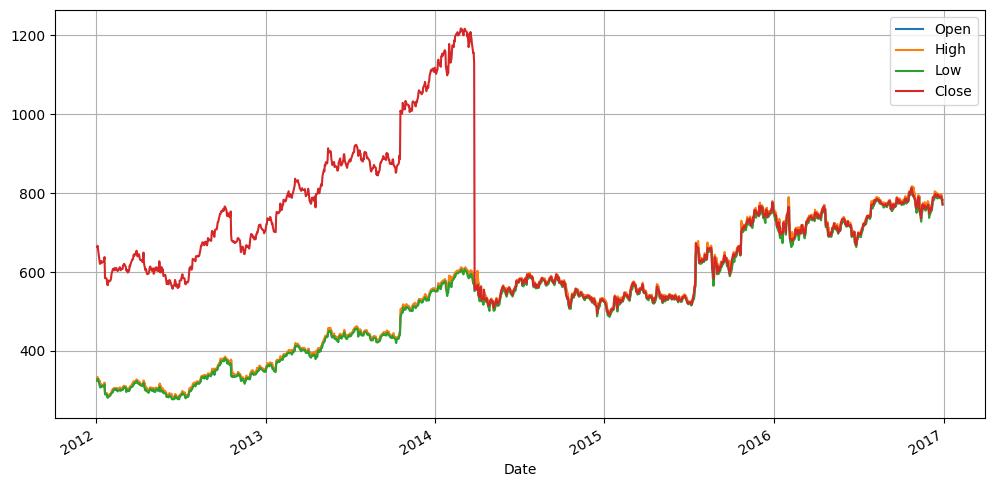

In [8]:
data.plot(x='Date',y=['Open','High','Low','Close'],figsize=(12,6))
plt.grid(True)
plt.show()

In [9]:
data.drop('Date',axis=1,inplace=True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Close   1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 49.3 KB


In [11]:
sc =MinMaxScaler()
data=sc.fit_transform(data)

In [14]:
def create_seq (data,idx,seqlen=60):
    x,y=[],[]
    for i in range(seqlen,len(data)):
        x.append(data[i-seqlen:i])
        y.append(data[i,idx])
    return np.array(x),np.array(y)
x,y= create_seq(data,3)
x

array([[[0.08581368, 0.09640129, 0.09044931, 0.23757287, 0.29525831],
        [0.09701243, 0.09834351, 0.09823458, 0.24151427, 0.22993592],
        [0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        ...,
        [0.07846566, 0.07903337, 0.0783452 , 0.21546794, 0.14593512],
        [0.08034452, 0.08276841, 0.08330808, 0.21229828, 0.16105326],
        [0.08497656, 0.08751191, 0.08921806, 0.22430164, 0.20379656]],

       [[0.09701243, 0.09834351, 0.09823458, 0.24151427, 0.22993592],
        [0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        [0.09156187, 0.08881917, 0.08800576, 0.21641884, 0.21617942],
        ...,
        [0.08034452, 0.08276841, 0.08330808, 0.21229828, 0.16105326],
        [0.08497656, 0.08751191, 0.08921806, 0.22430164, 0.20379656],
        [0.08627874, 0.08564439, 0.08283452, 0.21420007, 0.15438526]],

       [[0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        [0.09156187, 0.08881917, 0.08800576, 0.21641884, 0.2

In [15]:
y

array([0.21420007, 0.20434657, 0.21216047, ..., 0.40495845, 0.40184391,
       0.38672602])

In [16]:
split = int(0.8*len(data))
x_train = x[:split]
x_test = x[split:]
y_train = y[:split]
y_test = y[split:]

In [20]:
# using SimpleRNN
model_sr = Sequential()
model_sr.add(SimpleRNN(64,return_sequences=True,activation='tanh',input_shape=(x_train.shape[1],x_train.shape[2])))
model_sr.add(Dropout(0.2))
model_sr.add(SimpleRNN(64,return_sequences=True,activation='tanh'))
model_sr.add(Dropout(0.2))
model_sr.add(SimpleRNN(64,return_sequences=True,activation='tanh'))
model_sr.add(Dropout(0.2))
model_sr.add(SimpleRNN(64))
model_sr.add(Dropout(0.2))
model_sr.add(Dense(1))
model_sr.compile(optimizer='adam',loss='mse')
model_sr.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)             │ (None, 60, 64)              │           4,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, 60, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_6 (SimpleRNN)             │ (None, 60, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_7 (SimpleRNN)             │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,313 (114.50 KB)

 Trainable params: 29,313 (114.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
h_sr= model_sr.fit(
    x_train,y_train,
    batch_size=32,
    epochs=50,
    validation_data=(x_test,y_test),
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.5364 - val_loss: 0.0015
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.3265 - val_loss: 0.0266
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.2422 - val_loss: 0.0038
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.1897 - val_loss: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1657 - val_loss: 0.0020
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1354 - val_loss: 0.0288
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.1321 - val_loss: 0.0621
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1156 - val_loss: 0.0023
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0996 - val_loss: 0.0022
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0860 - val_loss: 0.0145
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0771 - val_loss: 0.0446
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0

In [25]:
y_pred= model_sr.predict(x_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [28]:
close_sc = MinMaxScaler()
close_sc.min_,close_sc.scale_ = sc.min_[3:4],sc.scale_[3:4]

In [29]:
predicted = close_sc.inverse_transform(y_pred)
actual = close_sc.inverse_transform(y_test.reshape(-1,1))

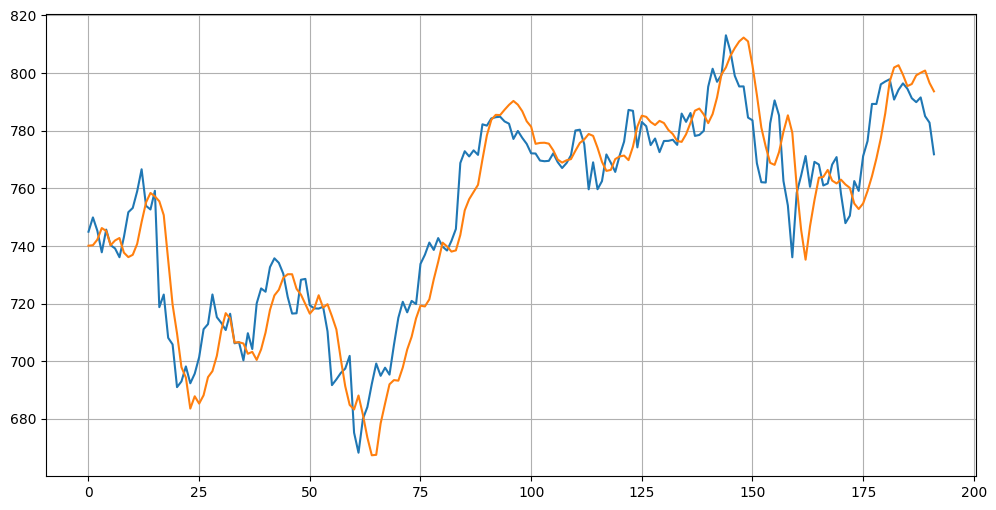

In [32]:
plt.figure(figsize=(12,6))
plt.plot(actual,label="Actual")
plt.plot(predicted,label="Predicted")
plt.grid(True)
plt.show()

In [34]:
print("RMSE : ",np.sqrt(mean_squared_error(actual,predicted)))
print("R2 score ",r2_score(actual,predicted))
print("MAE : ",mean_absolute_error(actual,predicted))

RMSE :  13.183648931907149
R2 score  0.8429887474888074
MAE :  10.38430875142416


In [36]:
# using LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(64,return_sequences=True,input_shape=(x_train.shape[1],x_train.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.1))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam',loss='mse')
model_lstm.summary()

C:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
h_lstm= model_lstm.fit(
    x_train,y_train,
    batch_size=32,
    epochs=50,
    validation_data=(x_test,y_test),
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0219 - val_loss: 0.0071
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0079 - val_loss: 6.1130e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0052 - val_loss: 8.0875e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0037 - val_loss: 6.4243e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0044 - val_loss: 4.3196e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0038 - val_loss: 0.0020
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0050 - val_loss: 5.1318e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0034 - val_loss: 0.0023
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0024 - val_loss: 3.6569e-04
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0062 - val_loss: 4.2131e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0030 - val_loss: 5.5847e-04
Epoch 12/50
32/32 ━━━━━━━━━━━━━

In [38]:
y_pred_lstm= model_lstm.predict(x_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [39]:
predicted_lstm = close_sc.inverse_transform(y_pred_lstm)
actual_lstm = close_sc.inverse_transform(y_test.reshape(-1,1))

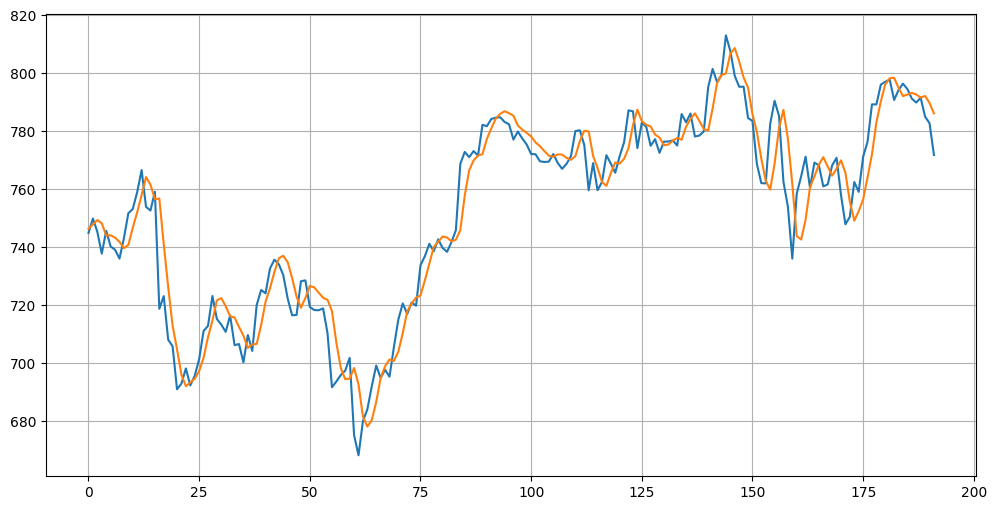

In [40]:
plt.figure(figsize=(12,6))
plt.plot(actual_lstm,label="Actual")
plt.plot(predicted_lstm,label="Predicted")
plt.grid(True)
plt.show()

In [41]:
print("RMSE : ",np.sqrt(mean_squared_error(actual_lstm,predicted_lstm)))
print("R2 score ",r2_score(actual_lstm,predicted_lstm))
print("MAE : ",mean_absolute_error(actual_lstm,predicted_lstm))

RMSE :  9.568670147101106
R2 score  0.9172891114737411
MAE :  7.0904124323527045
